## Numerical Methods for Solving Differential Equations

In [4]:
def euler(x0, v0, dt):
    a0 = fisica_del_pendulo(k, m, x0)
    x = x0 + v0*dt
    v = v0 + a0*dt
    return x, v

def euler_cromer(x0, v0, dt):
    a0 = fisica_del_pendulo(k, m, x0)
    v = v0 + a0*dt
    x = x0 + v*dt
    return x, v

def piccard(x0, v0, dt):
    a0 = fisica_del_pendulo(k, m, x0)
    v = v0 + a0*dt
    x = x0 + v0*dt
    a = fisica_del_pendulo(k, m, x)

    x = x0 + 0.5*(v0 + v)*dt
    v = v0 + 0.5*(a0 + a)*dt
    return x, v

def rk2(x0, v0, dt):

    xx, vv, aa = [np.zeros(3) for _ in range(3)]

    vv[1]= v0
    xx[1]= x0
    aa[1]= fisica_del_pendulo(k, m, xx[1])
    
    vv[2]= vv[1] + aa[1]*dt
    xx[2]= xx[1] + vv[1]*dt
    aa[2]= fisica_del_pendulo(k, m, xx[2])

    x= xx[1] + 0.5*(vv[1]+vv[2])*dt
    v= vv[1] + 0.5*(aa[1]+aa[2])*dt
    return x, v

def rk4(x0, v0, dt):

    xx, vv, aa = [np.zeros(5) for _ in range(3)]

    vv[1]= v0
    xx[1]= x0
    aa[1]= fisica_del_pendulo(k, m, xx[1])
    
    vv[2]= vv[1] + aa[1]*dt/2
    xx[2]= xx[1] + vv[1]*dt/2
    aa[2]= fisica_del_pendulo(k, m, xx[2])

    vv[3]= vv[1] + aa[2]*dt/2
    xx[3]= xx[1] + vv[2]*dt/2
    aa[3]= fisica_del_pendulo(k, m, xx[3])

    vv[4]= vv[1] + aa[3]*dt
    xx[4]= xx[1] + vv[3]*dt
    aa[4]= fisica_del_pendulo(k, m, xx[4])

    x= xx[1] + (vv[1]+ 2*vv[2]+ 2*vv[3]+ vv[4])*dt/6
    v= vv[1] + (aa[1]+ 2*aa[2]+ 2*aa[3]+ aa[4])*dt/6
    return x, v

def fisica_del_pendulo(k, m, x):
    a = -k/m * x
    return a

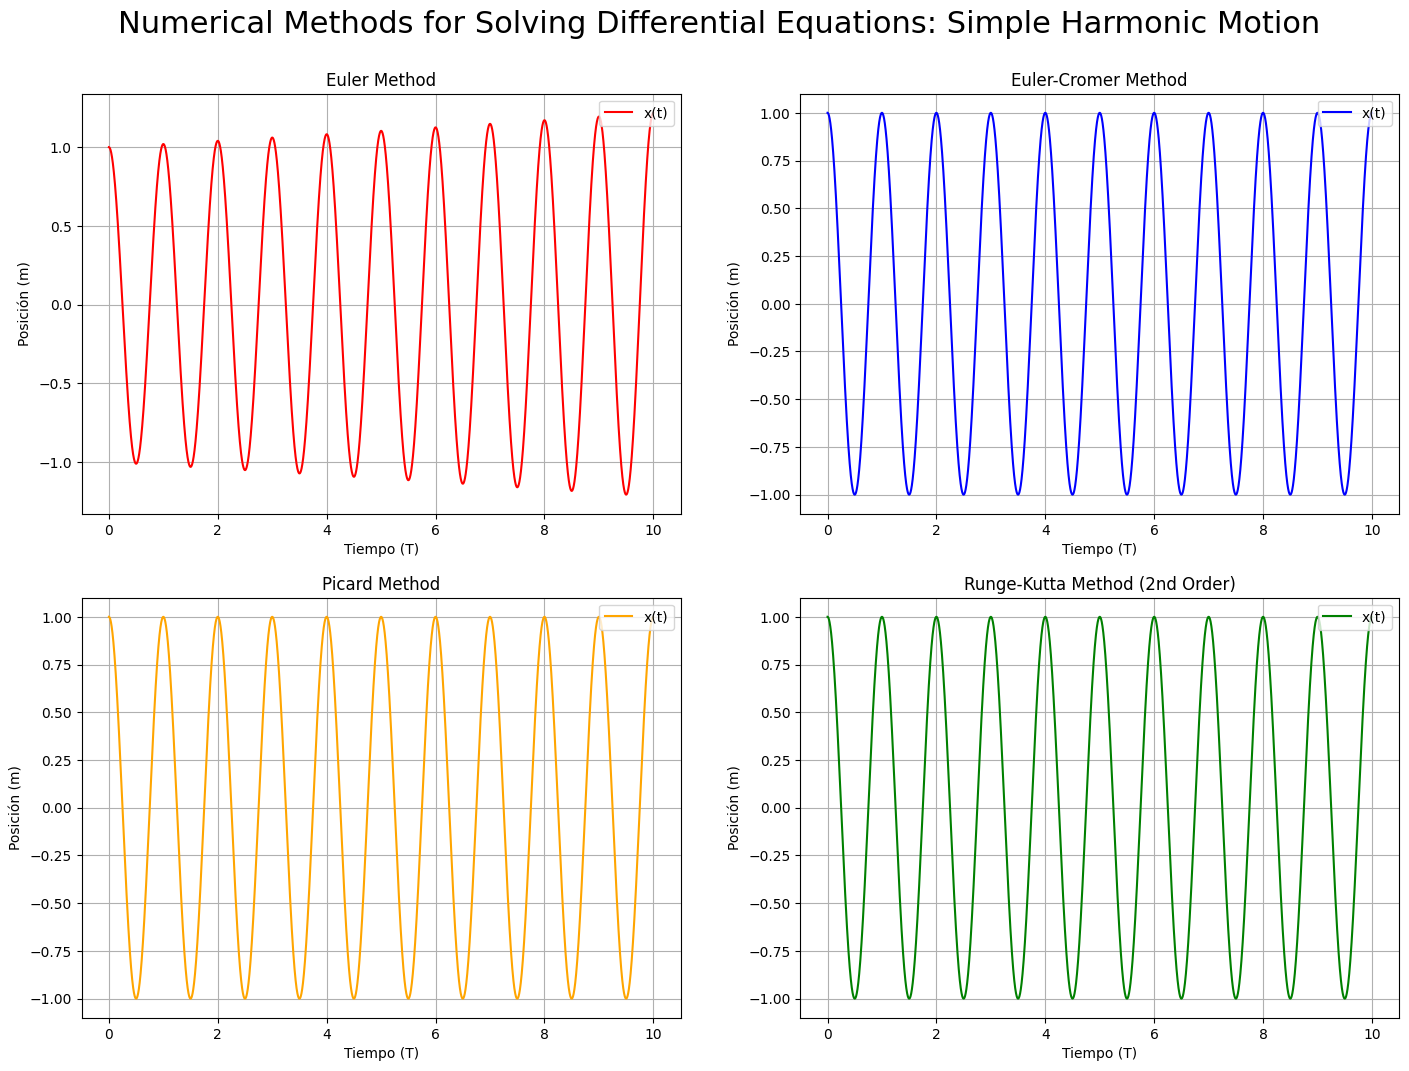

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del oscilador
m=1.0          # masa (kg)
k=1.0          # constante del resorte (N/m)
wo=np.sqrt(k/m)

# Condiciones iniciales
x0=1.0        # desplazamiento inicial (m)
v0=0.0        # velocidad inicial (m/s)

# Parámetros numéricos
resolucion=1000
T=2*np.pi/wo
dt=T/resolucion
numero_periodos=10*resolucion

t = np.zeros(numero_periodos)
x_e, x_ec, x_p, x_rk2 = [np.zeros(numero_periodos) for _ in range(4)]
v_e, v_ec, v_p, v_rk2 = [np.zeros(numero_periodos) for _ in range(4)]

t[0] = 0
x_e[0] = x0
x_ec[0] = x0
x_p[0] = x0
x_rk2[0] = x0
v_e[0] = v0
v_ec[0] = v0
v_p[0] = v0
v_rk2[0] = v0

for i in range(1,numero_periodos):
    t[i] = i*dt
    x_e[i], v_e[i] = euler(x_e[i-1], v_e[i-1], dt)
    x_ec[i], v_ec[i] = euler_cromer(x_ec[i-1], v_ec[i-1], dt)
    x_p[i], v_p[i] = piccard(x_p[i-1], v_p[i-1], dt)
    x_rk2[i], v_rk2[i] = rk2(x_rk2[i-1], v_rk2[i-1], dt)


plt.figure(figsize=(17, 12))

plt.subplot(2, 2, 1)
plt.plot(t/T, x_e, label='x(t)', color='red')
plt.title('Euler Method')
plt.xlabel('Tiempo (T)')
plt.ylabel('Posición (m)')
plt.legend(loc='upper right')
plt.grid(True)


plt.subplot(2, 2, 2)
plt.plot(t/T, x_ec, label='x(t)', color='blue')
plt.title('Euler-Cromer Method')
plt.xlabel('Tiempo (T)')
plt.ylabel('Posición (m)')
plt.legend(loc='upper right')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(t/T, x_p, label='x(t)', color='orange')
plt.title('Picard Method')
plt.xlabel('Tiempo (T)')
plt.ylabel('Posición (m)')
plt.legend(loc='upper right')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(t/T, x_rk2, label='x(t)', color='green')
plt.title('Runge-Kutta Method (2nd Order)')
plt.xlabel('Tiempo (T)')
plt.ylabel('Posición (m)')
plt.legend(loc='upper right')
plt.grid(True)

plt.suptitle(
    'Numerical Methods for Solving Differential Equations: Simple Harmonic Motion',
    fontsize=22, y=0.95
)

plt.show()


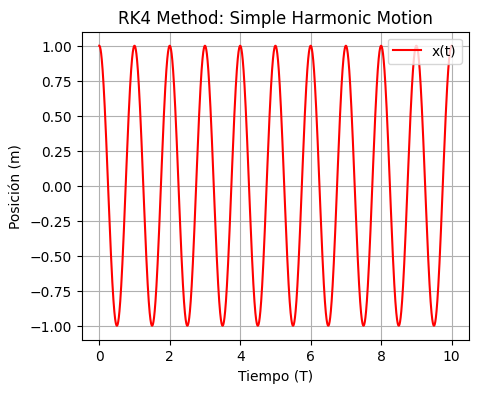

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del oscilador
m=1.0          # masa (kg)
k=1.0          # constante del resorte (N/m)
wo=np.sqrt(k/m)

# Condiciones iniciales
x0=1.0        # desplazamiento inicial (m)
v0=0.0        # velocidad inicial (m/s)

# Parámetros numéricos
resolucion=1000
T=2*np.pi/wo
dt=T/resolucion
numero_periodos=10*resolucion

t = np.zeros(numero_periodos)
x_rk4, v_rk4 = [np.zeros(numero_periodos) for _ in range(2)]

t[0] = 0
x_rk4[0] = x0
v_rk4[0] = v0

for i in range(1,numero_periodos):
    t[i] = i*dt
    x_rk4[i], v_rk4[i] = rk4(x_rk4[i-1], v_rk4[i-1], dt)


plt.figure(figsize=(5, 4))
plt.plot(t/T, x_rk4, label='x(t)', color='red')
plt.title('RK4 Method: Simple Harmonic Motion')
plt.xlabel('Tiempo (T)')
plt.ylabel('Posición (m)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()